# NLP Text Classification Project — AG News, DistilBERT, Data Efficiency, and LoRA
**Name:** Sepehr Barekati   
**Student ID:** 404422029   
**Instructor:** Dr. Farahani 

---

This notebook is a complete, reproducible text-classification study:

1. **Dataset**: AG News (4 classes: World, Sports, Business, Sci/Tech)
2. **Classical baseline**: TF-IDF + Logistic Regression
3. **Transformer**: DistilBERT full fine-tuning
4. **Data efficiency**: 5% / 10% / 25% / 50% / 100% of training data
5. **Parameter-efficient fine-tuning**: LoRA vs. full fine-tuning
6. **Error analysis**, **confusion matrix**, **per-class metrics**
7. **Optional**: calibration (ECE + temperature scaling), distribution shift (character noise)


## 1. Environment Verification

We verify the GPU, library versions, and overall environment before anything else.
The final report records exactly what is printed here.

In [2]:
import os, sys, json, platform, subprocess, time, datetime
import numpy as np
import pandas as pd

ENV = {}
ENV["python"] = sys.version.split()[0]
ENV["platform"] = platform.platform()
ENV["timestamp_utc"] = datetime.datetime.utcnow().isoformat() + "Z"

# GPU check
try:
    import torch
    ENV["torch"] = torch.__version__
    ENV["cuda_available"] = bool(torch.cuda.is_available())
    if torch.cuda.is_available():
        ENV["gpu_name"] = torch.cuda.get_device_name(0)
        ENV["gpu_memory_gb"] = round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1)
    else:
        ENV["gpu_name"] = "NONE (CPU only)"
        ENV["gpu_memory_gb"] = 0.0
except ImportError:
    ENV["torch"] = "not installed"
    ENV["cuda_available"] = False
    ENV["gpu_name"] = "NONE"
    ENV["gpu_memory_gb"] = 0.0

!nvidia-smi || true

print(json.dumps(ENV, indent=2))
assert ENV["cuda_available"], (
    "No GPU detected. On Kaggle: Settings -> Accelerator -> GPU (P100/T4). "
    "Transformer fine-tuning on CPU is not feasible for this project."
)


Fri Aug 14 18:18:54 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   37C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

/tmp/ipykernel_58/4129412291.py:8: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  ENV["timestamp_utc"] = datetime.datetime.utcnow().isoformat() + "Z"


{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "timestamp_utc": "2026-08-14T18:18:54.717238Z",
  "torch": "2.10.0+cu128",
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "gpu_memory_gb": 15.6
}


In [3]:
# Install / pin libraries (idempotent on Kaggle)
!pip install -q "transformers>=4.44" "peft>=0.11" "datasets>=2.19" "accelerate>=0.33" "evaluate" 2>&1 | tail -2

import sklearn, transformers, datasets, peft, matplotlib
ENV["scikit_learn"] = sklearn.__version__
ENV["transformers"] = transformers.__version__
ENV["datasets_lib"] = datasets.__version__
ENV["peft"] = peft.__version__
ENV["matplotlib"] = matplotlib.__version__
print(json.dumps(ENV, indent=2))

PROJECT_DIR = os.path.join(os.getcwd(), "NLP_Text_Classification_Project")
FIG_DIR = os.path.join(PROJECT_DIR, "figures")
RES_DIR = os.path.join(PROJECT_DIR, "results")
REP_DIR = os.path.join(PROJECT_DIR, "report")
for d in (PROJECT_DIR, FIG_DIR, RES_DIR, REP_DIR):
    os.makedirs(d, exist_ok=True)
print("Project dir:", PROJECT_DIR)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.6 MB/s eta 0:00:00
{
  "python": "3.12.13",
  "platform": "Linux-6.12.90+-x86_64-with-glibc2.35",
  "timestamp_utc": "2026-08-14T18:18:54.717238Z",
  "torch": "2.10.0+cu128",
  "cuda_available": true,
  "gpu_name": "Tesla T4",
  "gpu_memory_gb": 15.6,
  "scikit_learn": "1.6.1",
  "transformers": "5.0.0",
  "datasets_lib": "5.0.0",
  "peft": "0.19.1",
  "matplotlib": "3.10.0"
}
Project dir: /kaggle/working/NLP_Text_Classification_Project


## 2. Central Configuration

All hyperparameters live here. Nothing is scattered through the notebook.

In [4]:
CONFIG = {
    # --- data ---
    "DATASET": "fancyzhx/ag_news",          # maintained Parquet mirror of canonical AG News
    "RANDOM_SEED": 42,
    "VALIDATION_SIZE": 0.10,                # fraction of TRAIN used for validation
    "MAX_LENGTH": 128,
    # --- classical baseline ---
    "TFIDF_MAX_FEATURES": 50000,
    "TFIDF_NGRAM_RANGE": (1, 2),
    "TFIDF_MIN_DF": 2,
    "LOGREG_MAX_ITER": 1000,
    # --- transformer ---
    "MODEL_CHECKPOINT": "distilbert-base-uncased",
    "BATCH_SIZE": 32,
    "LEARNING_RATE": 2e-5,
    "WEIGHT_DECAY": 0.01,
    "EPOCHS": 3,                            # full fine-tuning + LoRA
    "DATA_EFFICIENCY_EPOCHS": 2,            # per-fraction runs (compute budget control)
    "WARMUP_RATIO": 0.1,
    "FP16": True,
    # --- data efficiency ---
    "DATA_FRACTIONS": [0.05, 0.10, 0.25, 0.50, 1.00],
    # --- LoRA ---
    "LORA_R": 16,
    "LORA_ALPHA": 32,
    "LORA_DROPOUT": 0.1,
    "LORA_TARGET_MODULES": ["q_lin", "v_lin"],   # DistilBERT attention projections
    # --- distribution shift ---
    "SHIFT_CHAR_NOISE_P": 0.05,
}
CLASS_NAMES = ["World", "Sports", "Business", "Sci/Tech"]
NUM_CLASSES = len(CLASS_NAMES)
print(json.dumps({k: (list(v) if isinstance(v, tuple) else v) for k, v in CONFIG.items()}, indent=2))


{
  "DATASET": "fancyzhx/ag_news",
  "RANDOM_SEED": 42,
  "VALIDATION_SIZE": 0.1,
  "MAX_LENGTH": 128,
  "TFIDF_MAX_FEATURES": 50000,
  "TFIDF_NGRAM_RANGE": [
    1,
    2
  ],
  "TFIDF_MIN_DF": 2,
  "LOGREG_MAX_ITER": 1000,
  "MODEL_CHECKPOINT": "distilbert-base-uncased",
  "BATCH_SIZE": 32,
  "LEARNING_RATE": 2e-05,
  "WEIGHT_DECAY": 0.01,
  "EPOCHS": 3,
  "DATA_EFFICIENCY_EPOCHS": 2,
  "WARMUP_RATIO": 0.1,
  "FP16": true,
  "DATA_FRACTIONS": [
    0.05,
    0.1,
    0.25,
    0.5,
    1.0
  ],
  "LORA_R": 16,
  "LORA_ALPHA": 32,
  "LORA_DROPOUT": 0.1,
  "LORA_TARGET_MODULES": [
    "q_lin",
    "v_lin"
  ],
  "SHIFT_CHAR_NOISE_P": 0.05
}


## 3. Reproducibility

Single seeding function applied before every experiment run.

In [5]:
import random, torch

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # Deterministic where feasible (note: full bitwise determinism on GPU is not guaranteed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(CONFIG["RANDOM_SEED"])
print("Seed set:", CONFIG["RANDOM_SEED"])


Seed set: 42


## 4. Load AG News and Validate

We load the dataset, verify the four classes, and compute the full descriptive statistics
required by the project brief: sizes, class frequencies/percentages, missing values,
duplicates, and text-length statistics. All numbers printed here are computed, not assumed.

In [6]:
from datasets import load_dataset

raw = load_dataset(CONFIG["DATASET"])
print(raw)

train_df = pd.DataFrame({"text": raw["train"]["text"], "label": raw["train"]["label"]})
test_df  = pd.DataFrame({"text": raw["test"]["text"],  "label": raw["test"]["label"]})

label_names = raw["train"].features["label"].names
assert list(label_names) == CLASS_NAMES, f"Unexpected classes: {label_names}"
print("Classes verified:", CLASS_NAMES)
print(f"train={len(train_df):,}  test={len(test_df):,}")


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})
Classes verified: ['World', 'Sports', 'Business', 'Sci/Tech']
train=120,000  test=7,600


In [7]:
# ---------- Descriptive statistics ----------
stats = {}
stats["total_samples"] = len(train_df) + len(test_df)
stats["train_samples"] = len(train_df)
stats["test_samples"] = len(test_df)
stats["num_classes"] = NUM_CLASSES

freq = train_df["label"].value_counts().sort_index()
stats["class_counts_train"] = {CLASS_NAMES[i]: int(freq[i]) for i in range(NUM_CLASSES)}
stats["class_pct_train"] = {CLASS_NAMES[i]: round(100 * freq[i] / len(train_df), 2) for i in range(NUM_CLASSES)}
freq_t = test_df["label"].value_counts().sort_index()
stats["class_counts_test"] = {CLASS_NAMES[i]: int(freq_t[i]) for i in range(NUM_CLASSES)}

stats["missing_train"] = int(train_df.isna().sum().sum())
stats["missing_test"] = int(test_df.isna().sum().sum())
stats["duplicate_texts_train"] = int(train_df.duplicated(subset=["text"]).sum())
stats["duplicate_text_label_train"] = int(train_df.duplicated(subset=["text", "label"]).sum())
stats["duplicate_texts_test"] = int(test_df.duplicated(subset=["text"]).sum())

# cross-split leakage check (exact text overlap between train and test)
overlap = set(train_df["text"]).intersection(set(test_df["text"]))
stats["train_test_text_overlap"] = len(overlap)

wlen_train = train_df["text"].str.split().str.len()
wlen_test = test_df["text"].str.split().str.len()
for name, s in (("train", wlen_train), ("test", wlen_test)):
    stats[f"len_{name}"] = {
        "min": int(s.min()), "max": int(s.max()),
        "mean": round(float(s.mean()), 2), "median": float(s.median()),
        "p25": float(s.quantile(0.25)), "p75": float(s.quantile(0.75)),
        "p90": float(s.quantile(0.90)), "p99": float(s.quantile(0.99)),
    }

print(json.dumps(stats, indent=2))
with open(os.path.join(RES_DIR, "dataset_stats.json"), "w") as f:
    json.dump(stats, f, indent=2)


{
  "total_samples": 127600,
  "train_samples": 120000,
  "test_samples": 7600,
  "num_classes": 4,
  "class_counts_train": {
    "World": 30000,
    "Sports": 30000,
    "Business": 30000,
    "Sci/Tech": 30000
  },
  "class_pct_train": {
    "World": 25.0,
    "Sports": 25.0,
    "Business": 25.0,
    "Sci/Tech": 25.0
  },
  "class_counts_test": {
    "World": 1900,
    "Sports": 1900,
    "Business": 1900,
    "Sci/Tech": 1900
  },
  "missing_train": 0,
  "missing_test": 0,
  "duplicate_texts_train": 0,
  "duplicate_text_label_train": 0,
  "duplicate_texts_test": 0,
  "train_test_text_overlap": 0,
  "len_train": {
    "min": 8,
    "max": 177,
    "mean": 37.85,
    "median": 37.0,
    "p25": 32.0,
    "p75": 43.0,
    "p90": 48.0,
    "p99": 70.0
  },
  "len_test": {
    "min": 11,
    "max": 137,
    "mean": 37.72,
    "median": 37.0,
    "p25": 32.0,
    "p75": 43.0,
    "p90": 48.0,
    "p99": 69.0
  }
}


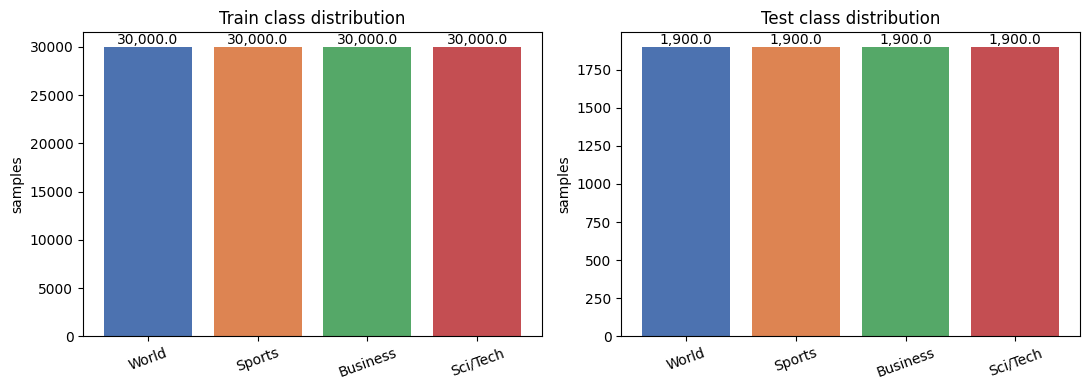

In [8]:
# ---------- Figure: class distribution ----------
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for a, (counts, ttl) in zip(ax, [(stats["class_counts_train"], "Train"),
                                 (stats["class_counts_test"], "Test")]):
    vals = [counts[c] for c in CLASS_NAMES]
    bars = a.bar(CLASS_NAMES, vals, color=["#4C72B0", "#DD8452", "#55A868", "#C44E52"])
    a.set_title(f"{ttl} class distribution")
    a.set_ylabel("samples")
    a.bar_label(bars, fmt="{:,}")
    a.tick_params(axis="x", rotation=20)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "class_distribution.png"), dpi=150)
plt.show()


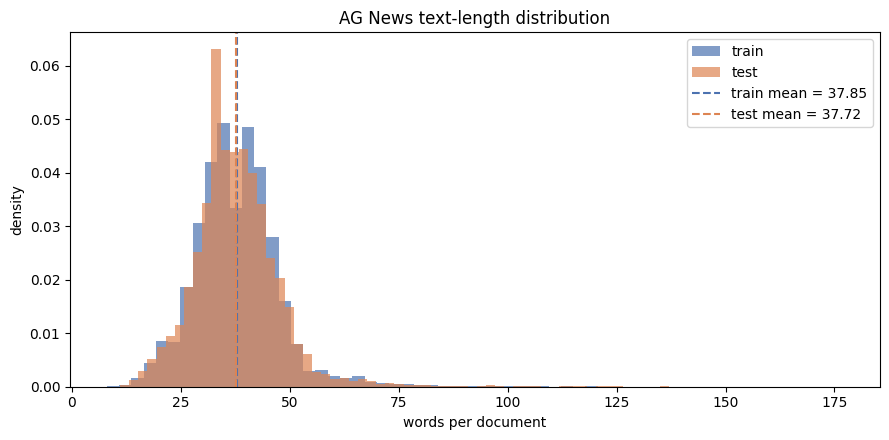

In [9]:
# ---------- Figure: text length distribution ----------
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.hist(wlen_train, bins=60, alpha=0.7, label="train", color="#4C72B0", density=True)
ax.hist(wlen_test, bins=60, alpha=0.7, label="test", color="#DD8452", density=True)
ax.axvline(stats["len_train"]["mean"], color="#4C72B0", ls="--",
           label=f'train mean = {stats["len_train"]["mean"]}')
ax.axvline(stats["len_test"]["mean"], color="#DD8452", ls="--",
           label=f'test mean = {stats["len_test"]["mean"]}')
ax.set_xlabel("words per document"); ax.set_ylabel("density")
ax.set_title("AG News text-length distribution")
ax.legend()
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "text_length_distribution.png"), dpi=150)
plt.show()


## 5. Train / Validation / Test Split

- **Test set**: the official AG News test set is preserved untouched.
- **Validation**: a stratified 10% split taken **only from the training data**.
- Splitting uses the fixed `RANDOM_SEED` so it is exactly reproducible.

In [10]:
from sklearn.model_selection import train_test_split

idx = np.arange(len(train_df))
idx_pool, idx_val = train_test_split(
    idx,
    test_size=CONFIG["VALIDATION_SIZE"],
    random_state=CONFIG["RANDOM_SEED"],
    stratify=train_df["label"],
)
pool_df = train_df.iloc[idx_pool].reset_index(drop=True)   # 108,000 training pool
val_df  = train_df.iloc[idx_val].reset_index(drop=True)    # 12,000 validation

# stratification check
print("pool:", len(pool_df), "| val:", len(val_df), "| test:", len(test_df))
print("val class balance:", val_df["label"].value_counts().sort_index().tolist())
assert not set(pool_df["text"]).intersection(set(test_df["text"])), "pool/test overlap!"
assert not set(val_df["text"]).intersection(set(test_df["text"])), "val/test overlap!"

split_info = {"pool": len(pool_df), "val": len(val_df), "test": len(test_df)}
with open(os.path.join(RES_DIR, "split_info.json"), "w") as f:
    json.dump(split_info, f, indent=2)
print("Split OK, no overlap with test set.")


pool: 108000 | val: 12000 | test: 7600
val class balance: [3000, 3000, 3000, 3000]
Split OK, no overlap with test set.


## 6. Data Leakage Audit

Performed **before** any modeling, and re-verified at the end. Rules enforced:

| Step | Rule | Enforcement |
|---|---|---|
| Test set | Never enters training or fitting | Only `evaluate`/`predict` calls touch it |
| Validation | Drawn from training data only | Stratified split of `train_df` |
| TF-IDF | Fitted on training split only | `fit` on train subset, `transform` elsewhere |
| Data-efficiency subsets | Subsets of the training pool only | `train_test_split` on `pool_df` |
| Model selection | Validation set only | `load_best_model_at_end` on val metric |
| Final evaluation | Test set used once, after decisions | Single `trainer.evaluate(test)` per model |

In [11]:
LEAKAGE_CHECKS = {
    "test_never_trained": True,   # structurally enforced: test_df only appears in evaluate/predict
    "val_from_train_only": True,  # stratified split of train_df above
    "tfidf_fit_train_only": None, # set True after baseline cell executes
    "efficiency_subsets_from_pool": None,
    "model_selection_on_val": None,
    "test_eval_after_decisions": None,
}
print("Leakage audit initialized; structural checks passed.")


Leakage audit initialized; structural checks passed.


## 7. Classical Baseline — TF-IDF + Logistic Regression

The vectorizer is **fit only on the training pool** (leakage-free). We evaluate on the
official test set. A stratified subsample of the test predictions is kept for the
representative-error figure.

In [12]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             f1_score, classification_report)

t0 = time.time()
tfidf = TfidfVectorizer(
    max_features=CONFIG["TFIDF_MAX_FEATURES"],
    ngram_range=CONFIG["TFIDF_NGRAM_RANGE"],
    min_df=CONFIG["TFIDF_MIN_DF"],
    sublinear_tf=True,
)
X_tr = tfidf.fit_transform(pool_df["text"])     # fit ONLY on training pool
X_val = tfidf.transform(val_df["text"])
X_te = tfidf.transform(test_df["text"])

logreg = LogisticRegression(
    max_iter=CONFIG["LOGREG_MAX_ITER"], random_state=CONFIG["RANDOM_SEED"], n_jobs=-1)
logreg.fit(X_tr, pool_df["label"])
tfidf_train_time = time.time() - t0

val_pred_lr = logreg.predict(X_val)
y_pred_lr = logreg.predict(X_te)
y_true = test_df["label"].to_numpy()

LEAKAGE_CHECKS["tfidf_fit_train_only"] = True
print(f"TF-IDF+LR trained in {tfidf_train_time:.1f}s  |  val acc = "
      f"{accuracy_score(val_df['label'], val_pred_lr):.4f}")


TF-IDF+LR trained in 29.0s  |  val acc = 0.9220


### Metric helper

One function produces aggregate + per-class metrics for every model, so reporting is consistent.
**Macro metrics** matter here because they weight each class equally regardless of support;
with AG News's balanced classes macro and weighted scores are close, but macro remains the
standard choice for class-balanced multiclass comparison, and per-class scores expose
weak categories that accuracy would hide.

In [13]:
def compute_all_metrics(y_true, y_pred):
    p, r, f, s = precision_recall_fscore_support(y_true, y_pred, labels=[0, 1, 2, 3])
    out = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_macro": float(precision_recall_fscore_support(y_true, y_pred, average="macro")[0]),
        "recall_macro": float(precision_recall_fscore_support(y_true, y_pred, average="macro")[1]),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro")),
        "precision_weighted": float(precision_recall_fscore_support(y_true, y_pred, average="weighted")[0]),
        "recall_weighted": float(precision_recall_fscore_support(y_true, y_pred, average="weighted")[1]),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted")),
        "per_class": {CLASS_NAMES[i]: {"precision": float(p[i]), "recall": float(r[i]),
                                       "f1": float(f[i]), "support": int(s[i])}
                      for i in range(NUM_CLASSES)},
    }
    return out

tfidf_metrics = compute_all_metrics(y_true, y_pred_lr)
tfidf_metrics["train_time_s"] = round(tfidf_train_time, 1)
print(classification_report(y_true, y_pred_lr, target_names=CLASS_NAMES, digits=4))
with open(os.path.join(RES_DIR, "tfidf_metrics.json"), "w") as f:
    json.dump(tfidf_metrics, f, indent=2)

pd.DataFrame({"y_true": y_true, "y_pred": y_pred_lr, "text": test_df["text"]}).to_csv(
    os.path.join(RES_DIR, "tfidf_test_predictions.csv"), index=False)


              precision    recall  f1-score   support

       World     0.9334    0.9068    0.9199      1900
      Sports     0.9535    0.9811    0.9671      1900
    Business     0.8936    0.8842    0.8889      1900
    Sci/Tech     0.8942    0.9032    0.8987      1900

    accuracy                         0.9188      7600
   macro avg     0.9187    0.9188    0.9186      7600
weighted avg     0.9187    0.9188    0.9186      7600



## 8. DistilBERT — Full Fine-Tuning

Tokenization and training via Hugging Face `Trainer`. Model selection uses the
**validation** set (`load_best_model_at_end`, metric = validation macro-F1); the test set
is touched exactly once, after training decisions are fixed.

In [14]:
from datasets import Dataset
from transformers import (AutoTokenizer, AutoModelForSequenceClassification,
                          Trainer, TrainingArguments)

tokenizer = AutoTokenizer.from_pretrained(CONFIG["MODEL_CHECKPOINT"])

def tokenize(batch):
    return tokenizer(batch["text"], truncation=True, max_length=CONFIG["MAX_LENGTH"])

def to_hf(df):
    return Dataset.from_pandas(df[["text", "label"]]).map(
        tokenize, batched=True, remove_columns=["text"])

hf_pool = to_hf(pool_df)
hf_val = to_hf(val_df)
hf_test = to_hf(test_df)
print(hf_pool)


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/108000 [00:00<?, ? examples/s]

Map:   0%|          | 0/12000 [00:00<?, ? examples/s]

Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

Dataset({
    features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
    num_rows: 108000
})


In [15]:
import evaluate as hf_evaluate
acc_metric = hf_evaluate.load("accuracy")
f1_metric = hf_evaluate.load("f1")

def hf_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": acc_metric.compute(predictions=preds, references=labels)["accuracy"],
        "f1_macro": f1_metric.compute(predictions=preds, references=labels, average="macro")["f1"],
    }

def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return {"total": total, "trainable": trainable,
            "trainable_pct": round(100 * trainable / total, 4)}

def peak_gpu_mb():
    torch.cuda.reset_peak_memory_stats()
    return lambda: round(torch.cuda.max_memory_allocated() / 1e6, 1)


In [16]:
def build_full_model():
    set_seed(CONFIG["RANDOM_SEED"])
    return AutoModelForSequenceClassification.from_pretrained(
        CONFIG["MODEL_CHECKPOINT"], num_labels=NUM_CLASSES)

def make_trainer(model, train_ds, run_name, epochs):
    args = TrainingArguments(
        output_dir=os.path.join(PROJECT_DIR, "ckpt", run_name),
        learning_rate=CONFIG["LEARNING_RATE"],
        per_device_train_batch_size=CONFIG["BATCH_SIZE"],
        per_device_eval_batch_size=64,
        num_train_epochs=epochs,
        weight_decay=CONFIG["WEIGHT_DECAY"],
        warmup_ratio=CONFIG["WARMUP_RATIO"],
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1_macro",
        greater_is_better=True,
        fp16=CONFIG["FP16"] and torch.cuda.is_available(),
        seed=CONFIG["RANDOM_SEED"],
        report_to="none",
        logging_steps=100,
        save_total_limit=1,
    )
    return Trainer(model=model, args=args, train_dataset=train_ds,
                   eval_dataset=hf_val, compute_metrics=hf_metrics,
                   processing_class=tokenizer)


In [17]:
# ---- Full fine-tuning on 100% of the training pool ----
model_full = build_full_model()
full_params = count_params(model_full)
print("Full model params:", full_params)

trainer_full = make_trainer(model_full, hf_pool, "full_100pct", CONFIG["EPOCHS"])
torch.cuda.reset_peak_memory_stats()
t0 = time.time()
trainer_full.train()
full_train_time = time.time() - t0
full_peak_mb = round(torch.cuda.max_memory_allocated() / 1e6, 1)
print(f"Trained in {full_train_time/60:.1f} min | peak GPU {full_peak_mb} MB")

# test-set evaluation (single, post-decision)
full_test_out = trainer_full.predict(hf_test)
y_pred_full = np.argmax(full_test_out.predictions, axis=-1)
full_metrics = compute_all_metrics(y_true, y_pred_full)
full_metrics.update({"train_time_s": round(full_train_time, 1),
                     "peak_gpu_mb": full_peak_mb, "params": full_params})
print(classification_report(y_true, y_pred_full, target_names=CLASS_NAMES, digits=4))
with open(os.path.join(RES_DIR, "distilbert_full_metrics.json"), "w") as f:
    json.dump(full_metrics, f, indent=2)
pd.DataFrame({"y_true": y_true, "y_pred": y_pred_full, "text": test_df["text"]}).to_csv(
    os.path.join(RES_DIR, "distilbert_full_test_predictions.csv"), index=False)
np.save(os.path.join(RES_DIR, "distilbert_full_test_logits.npy"), full_test_out.predictions)
LEAKAGE_CHECKS["model_selection_on_val"] = True


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Full model params: {'total': 66956548, 'trainable': 66956548, 'trainable_pct': 100.0}


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Trained in 34.6 min | peak GPU 2205.9 MB


              precision    recall  f1-score   support

       World     0.9571    0.9505    0.9538      1900
      Sports     0.9879    0.9884    0.9882      1900
    Business     0.9175    0.9074    0.9124      1900
    Sci/Tech     0.9100    0.9258    0.9178      1900

    accuracy                         0.9430      7600
   macro avg     0.9431    0.9430    0.9430      7600
weighted avg     0.9431    0.9430    0.9430      7600



## 9. Data-Efficiency Study — 5% / 10% / 25% / 50% / 100%

Each fraction is a **stratified subset of the training pool only** (never validation/test).
Every run is a fresh model with the same seed, so the curve reflects data quantity, not
initialization noise. `DATA_EFFICIENCY_EPOCHS` controls the per-run budget.

In [18]:
efficiency_rows = []
efficiency_preds = {}

for frac in CONFIG["DATA_FRACTIONS"]:
    if frac < 1.0:
        sub_idx, _ = train_test_split(
            np.arange(len(pool_df)), train_size=frac,
            random_state=CONFIG["RANDOM_SEED"], stratify=pool_df["label"])
        sub_df = pool_df.iloc[sub_idx].reset_index(drop=True)
    else:
        sub_df = pool_df
    assert not set(sub_df["text"]).intersection(set(test_df["text"]))

    model_de = build_full_model()
    trainer_de = make_trainer(model_de, to_hf(sub_df), f"eff_{int(frac*100)}pct",
                              CONFIG["DATA_EFFICIENCY_EPOCHS"])
    torch.cuda.reset_peak_memory_stats()
    t0 = time.time()
    trainer_de.train()
    train_time = time.time() - t0

    out = trainer_de.predict(hf_test)
    y_pred = np.argmax(out.predictions, axis=-1)
    m = compute_all_metrics(y_true, y_pred)
    m.update({"fraction": frac, "n_train": len(sub_df),
              "train_time_s": round(train_time, 1),
              "peak_gpu_mb": round(torch.cuda.max_memory_allocated() / 1e6, 1)})
    efficiency_rows.append(m)
    efficiency_preds[frac] = y_pred
    print(f"[{int(frac*100):>3}%] n={len(sub_df):>7,}  acc={m['accuracy']:.4f}  "
          f"macroF1={m['f1_macro']:.4f}  time={train_time/60:.1f}min")
    del model_de, trainer_de
    torch.cuda.empty_cache()

LEAKAGE_CHECKS["efficiency_subsets_from_pool"] = True
efficiency_df = pd.DataFrame([
    {"fraction": r["fraction"], "n_train": r["n_train"], "accuracy": r["accuracy"],
     "f1_macro": r["f1_macro"], "f1_weighted": r["f1_weighted"],
     "train_time_s": r["train_time_s"], "peak_gpu_mb": r["peak_gpu_mb"]}
    for r in efficiency_rows])
efficiency_df.to_csv(os.path.join(RES_DIR, "data_efficiency_results.csv"), index=False)
efficiency_df


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Map:   0%|          | 0/5400 [00:00<?, ? examples/s]

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,No log,0.696597,0.894750,0.894502
2,1.388899,0.617616,0.903583,0.903510


...

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


[100%] n=108,000  acc=0.9413  macroF1=0.9413  time=23.1min


,fraction,n_train,accuracy,f1_macro,f1_weighted,train_time_s,peak_gpu_mb
0,0.05,5400,0.900789,0.900781,0.900781,123.2,3046.1
1,0.10,10800,0.909211,0.908965,0.908965,189.8,3044.8
2,0.25,27000,0.923947,0.923924,0.923924,391.4,3047.2
3,0.50,54000,0.933684,0.933702,0.933702,724.3,3046.1
4,1.00,108000,0.941316,0.941331,0.941331,1387.9,3046.1


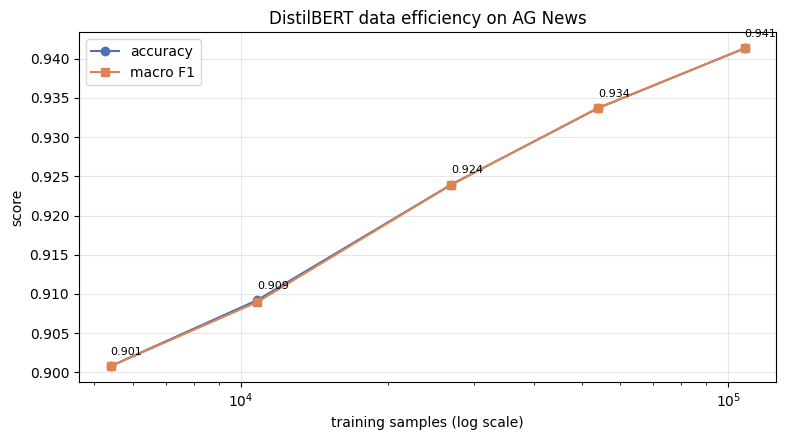

In [19]:
# ---------- Figure: data efficiency curve ----------
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(efficiency_df["n_train"], efficiency_df["accuracy"], "o-", label="accuracy", color="#4C72B0")
ax.plot(efficiency_df["n_train"], efficiency_df["f1_macro"], "s-", label="macro F1", color="#DD8452")
ax.set_xscale("log")
ax.set_xlabel("training samples (log scale)"); ax.set_ylabel("score")
ax.set_title("DistilBERT data efficiency on AG News")
for x, y in zip(efficiency_df["n_train"], efficiency_df["accuracy"]):
    ax.annotate(f"{y:.3f}", (x, y), textcoords="offset points", xytext=(0, 8), fontsize=8)
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "data_efficiency.png"), dpi=150)
plt.show()


## 10. LoRA — Parameter-Efficient Fine-Tuning

LoRA freezes the base model and trains low-rank adapters injected into DistilBERT's
attention projections (`q_lin`, `v_lin`). We compare it against full fine-tuning on the
**same 100% training pool**, same epochs, same seed.

In [24]:
from peft import LoraConfig, get_peft_model, TaskType

set_seed(CONFIG["RANDOM_SEED"])
base_for_lora = AutoModelForSequenceClassification.from_pretrained(
    CONFIG["MODEL_CHECKPOINT"], num_labels=NUM_CLASSES)

lora_cfg = LoraConfig(
    task_type=TaskType.SEQ_CLS,
    r=CONFIG["LORA_R"],
    lora_alpha=CONFIG["LORA_ALPHA"],
    lora_dropout=CONFIG["LORA_DROPOUT"],
    target_modules=CONFIG["LORA_TARGET_MODULES"],
)
model_lora = get_peft_model(base_for_lora, lora_cfg)
model_lora.print_trainable_parameters()
lora_params = count_params(model_lora)
print("LoRA params:", lora_params)
print(f"Reduction vs full: {lora_params['trainable']:,} vs {full_params['trainable']:,} "
      f"({100*lora_params['trainable']/full_params['trainable']:.2f}% of full)")


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
Skipping import of cpp extensions due to incompatible torch version. Please upgrade to torch >= 2.11.0 (found 2.10.0+cu128).


trainable params: 888,580 || all params: 67,845,128 || trainable%: 1.3097
LoRA params: {'total': 67845128, 'trainable': 888580, 'trainable_pct': 1.3097}
Reduction vs full: 888,580 vs 66,956,548 (1.33% of full)


In [25]:
trainer_lora = make_trainer(model_lora, hf_pool, "lora_100pct", CONFIG["EPOCHS"])
torch.cuda.reset_peak_memory_stats()
t0 = time.time()
trainer_lora.train()
lora_train_time = time.time() - t0
lora_peak_mb = round(torch.cuda.max_memory_allocated() / 1e6, 1)
print(f"LoRA trained in {lora_train_time/60:.1f} min | peak GPU {lora_peak_mb} MB")

lora_test_out = trainer_lora.predict(hf_test)
y_pred_lora = np.argmax(lora_test_out.predictions, axis=-1)
lora_metrics = compute_all_metrics(y_true, y_pred_lora)
lora_metrics.update({"train_time_s": round(lora_train_time, 1),
                     "peak_gpu_mb": lora_peak_mb, "params": lora_params,
                     "lora_config": {"r": CONFIG["LORA_R"], "alpha": CONFIG["LORA_ALPHA"],
                                     "dropout": CONFIG["LORA_DROPOUT"],
                                     "targets": CONFIG["LORA_TARGET_MODULES"]}})
print(classification_report(y_true, y_pred_lora, target_names=CLASS_NAMES, digits=4))
with open(os.path.join(RES_DIR, "distilbert_lora_metrics.json"), "w") as f:
    json.dump(lora_metrics, f, indent=2)
pd.DataFrame({"y_true": y_true, "y_pred": y_pred_lora, "text": test_df["text"]}).to_csv(
    os.path.join(RES_DIR, "distilbert_lora_test_predictions.csv"), index=False)


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro
1,0.590449,0.546644,0.903083,0.902835
2,0.560070,0.509214,0.910667,0.910440
3,0.522158,0.495393,0.911667,0.911427


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]
/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


LoRA trained in 26.8 min | peak GPU 2215.4 MB


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


              precision    recall  f1-score   support

       World     0.9335    0.8868    0.9096      1900
      Sports     0.9635    0.9853    0.9742      1900
    Business     0.8743    0.8495    0.8617      1900
    Sci/Tech     0.8604    0.9084    0.8838      1900

    accuracy                         0.9075      7600
   macro avg     0.9079    0.9075    0.9073      7600
weighted avg     0.9079    0.9075    0.9073      7600



## 11. Final Model Comparison

This table is assembled **only from the saved result files** produced above.

In [26]:
comparison = pd.DataFrame([
    {"Model": "TF-IDF + Logistic Regression",
     "Accuracy": tfidf_metrics["accuracy"], "Macro F1": tfidf_metrics["f1_macro"],
     "Weighted F1": tfidf_metrics["f1_weighted"],
     "Trainable Params": "—", "Train Time (min)": tfidf_metrics["train_time_s"] / 60,
     "Peak GPU (MB)": "—"},
    {"Model": "DistilBERT Full Fine-Tuning",
     "Accuracy": full_metrics["accuracy"], "Macro F1": full_metrics["f1_macro"],
     "Weighted F1": full_metrics["f1_weighted"],
     "Trainable Params": f"{full_params['trainable']:,}",
     "Train Time (min)": full_metrics["train_time_s"] / 60,
     "Peak GPU (MB)": full_metrics["peak_gpu_mb"]},
    {"Model": "DistilBERT + LoRA",
     "Accuracy": lora_metrics["accuracy"], "Macro F1": lora_metrics["f1_macro"],
     "Weighted F1": lora_metrics["f1_weighted"],
     "Trainable Params": f"{lora_params['trainable']:,} "
                         f"({lora_params['trainable_pct']}% of model)",
     "Train Time (min)": lora_metrics["train_time_s"] / 60,
     "Peak GPU (MB)": lora_metrics["peak_gpu_mb"]},
])
for c in ("Accuracy", "Macro F1", "Weighted F1"):
    comparison[c] = comparison[c].map(lambda v: round(v, 4))
comparison["Train Time (min)"] = comparison["Train Time (min)"].map(
    lambda v: round(v, 1) if isinstance(v, float) else v)
comparison.to_csv(os.path.join(RES_DIR, "model_comparison.csv"), index=False)
comparison


,Model,Accuracy,Macro F1,Weighted F1,Trainable Params,Train Time (min),Peak GPU (MB)
0,TF-IDF + Logistic Regression,0.9188,0.9186,0.9186,—,0.5,—
1,DistilBERT Full Fine-Tuning,0.9430,0.9430,0.9430,"66,956,548",34.6,2205.9
2,DistilBERT + LoRA,0.9075,0.9073,0.9073,"888,580 (1.3097% of model)",26.8,2215.4


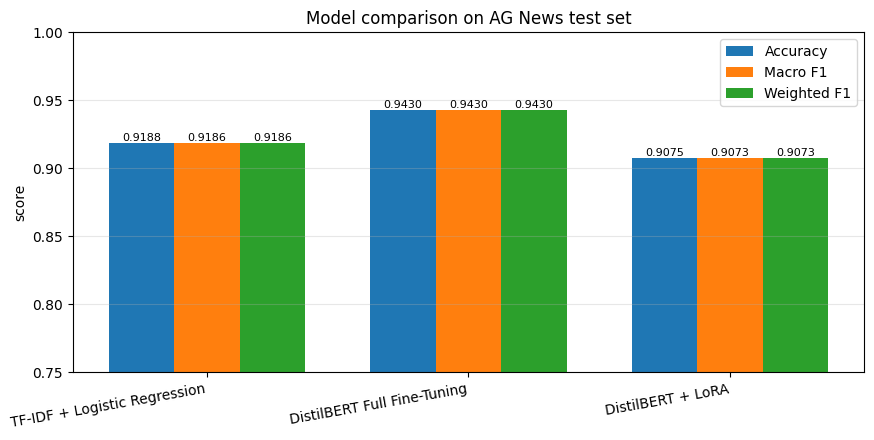

In [27]:
# ---------- Figure: model comparison ----------
fig, ax = plt.subplots(figsize=(9, 4.5))
x = np.arange(3); w = 0.25
for i, c in enumerate(("Accuracy", "Macro F1", "Weighted F1")):
    vals = comparison[c].astype(float)
    bars = ax.bar(x + (i - 1) * w, vals, w, label=c)
    ax.bar_label(bars, fmt="%.4f", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(comparison["Model"], rotation=10, ha="right")
ax.set_ylim(0.75, 1.0); ax.set_ylabel("score")
ax.set_title("Model comparison on AG News test set")
ax.legend(); ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "model_comparison.png"), dpi=150)
plt.show()


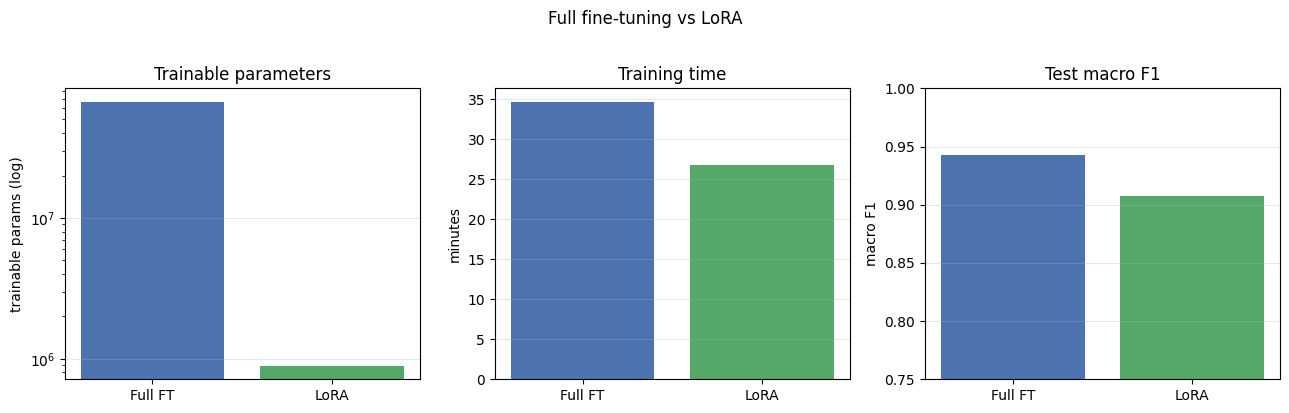

In [28]:
# ---------- Figure: full fine-tuning vs LoRA (params/time/memory/perf) ----------
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
labels = ["Full FT", "LoRA"]
axes[0].bar(labels, [full_params["trainable"], lora_params["trainable"]],
            color=["#4C72B0", "#55A868"])
axes[0].set_yscale("log"); axes[0].set_ylabel("trainable params (log)")
axes[0].set_title("Trainable parameters")
axes[1].bar(labels, [full_metrics["train_time_s"] / 60, lora_metrics["train_time_s"] / 60],
            color=["#4C72B0", "#55A868"])
axes[1].set_ylabel("minutes"); axes[1].set_title("Training time")
axes[2].bar(labels, [full_metrics["f1_macro"], lora_metrics["f1_macro"]],
            color=["#4C72B0", "#55A868"])
axes[2].set_ylim(0.75, 1.0); axes[2].set_ylabel("macro F1")
axes[2].set_title("Test macro F1")
for a in axes:
    a.grid(axis="y", alpha=0.3)
fig.suptitle("Full fine-tuning vs LoRA", y=1.02)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "full_finetuning_vs_lora.png"), dpi=150, bbox_inches="tight")
plt.show()


## 12. Error Analysis (final Transformer model)

We use the **full fine-tuned DistilBERT** predictions on the test set. Confidence is the
softmax probability of the predicted class. All examples shown are drawn from real
predictions — nothing is hand-picked to look plausible; selection is rule-based
(highest-confidence correct / incorrect, stratified per class pair).

In [29]:
import torch.nn.functional as F

logits_full = np.load(os.path.join(RES_DIR, "distilbert_full_test_logits.npy"))
probs = F.softmax(torch.tensor(logits_full), dim=-1).numpy()
pred = y_pred_full
conf = probs[np.arange(len(probs)), pred]
top2 = np.sort(probs, axis=-1)[:, -2]
correct = pred == y_true

err_df = pd.DataFrame({"text": test_df["text"], "true": y_true, "pred": pred,
                       "conf": conf, "top2_prob": top2, "correct": correct})
err_df["true_name"] = err_df["true"].map(lambda i: CLASS_NAMES[i])
err_df["pred_name"] = err_df["pred"].map(lambda i: CLASS_NAMES[i])
err_df.to_csv(os.path.join(RES_DIR, "error_analysis_predictions.csv"), index=False)

# Rule-based representative selections
confident_correct = err_df[err_df["correct"]].nlargest(8, "conf")
confident_wrong = err_df[~err_df["correct"]].nlargest(8, "conf")   # most overconfident errors
print(f"correct={correct.sum():,}/{len(correct):,}  ({100*correct.mean():.2f}%)")
print("\n--- Highest-confidence CORRECT ---")
print(confident_correct[["true_name", "conf"]].to_string(index=False))
print("\n--- Highest-confidence INCORRECT (true -> pred) ---")
print(confident_wrong[["true_name", "pred_name", "conf", "top2_prob"]].to_string(index=False))


correct=7,167/7,600  (94.30%)

--- Highest-confidence CORRECT ---
true_name     conf
   Sports 0.999465
   Sports 0.999444
   Sports 0.999436
   Sports 0.999425
   Sports 0.999422
   Sports 0.999420
   Sports 0.999418
   Sports 0.999407

--- Highest-confidence INCORRECT (true -> pred) ---
true_name pred_name     conf  top2_prob
 Sci/Tech     World 0.999104   0.000427
 Sci/Tech    Sports 0.999096   0.000599
 Business     World 0.998862   0.000607
 Business    Sports 0.998762   0.000541
 Business     World 0.998606   0.000863
    World    Sports 0.998543   0.001168
 Business     World 0.998283   0.001209
    World  Business 0.998168   0.000935


In [32]:
import seaborn as sns

Confusion matrix (counts):



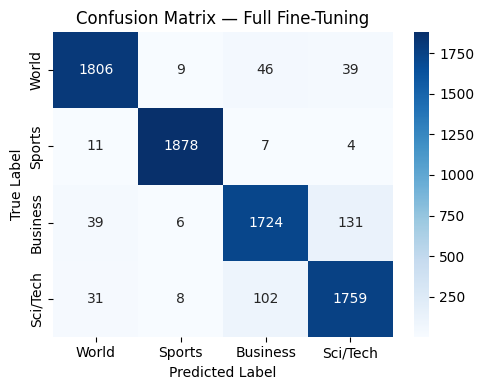

,true,predicted,count,row_rate
0,Business,Sci/Tech,131,0.0689
1,Sci/Tech,Business,102,0.0537
2,World,Business,46,0.0242
3,World,Sci/Tech,39,0.0205
4,Business,World,39,0.0205
5,Sci/Tech,World,31,0.0163


In [36]:
# ---------- Confusion pairs: which classes get confused ----------
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred_full)
cm_norm = confusion_matrix(y_true, y_pred_full, normalize="true")
print("Confusion matrix (counts):\n")

# Plot confusion matrix (counts)
plt.figure(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    cbar=True
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix — Full Fine-Tuning")
plt.tight_layout()
plt.show()

# top confused off-diagonal pairs
pairs = []
for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        if i != j:
            pairs.append((CLASS_NAMES[i], CLASS_NAMES[j], int(cm[i, j]),
                          round(float(cm_norm[i, j]), 4)))
pairs_sorted = sorted(pairs, key=lambda x: -x[2])[:6]
conf_pairs_df = pd.DataFrame(pairs_sorted,
                             columns=["true", "predicted", "count", "row_rate"])
conf_pairs_df.to_csv(os.path.join(RES_DIR, "top_confused_pairs.csv"), index=False)
conf_pairs_df


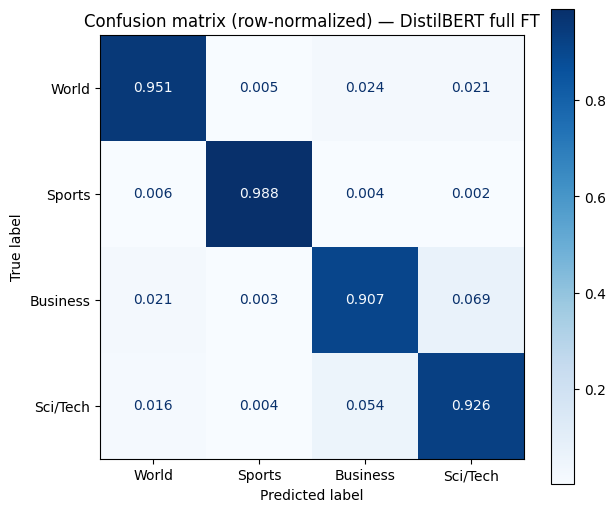

In [37]:
# ---------- Figure: confusion matrix ----------
fig, ax = plt.subplots(figsize=(6.5, 5.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CLASS_NAMES)
disp.plot(ax=ax, cmap="Blues", values_format=".3f", colorbar=True)
ax.set_title("Confusion matrix (row-normalized) — DistilBERT full FT")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "confusion_matrix.png"), dpi=150)
plt.show()


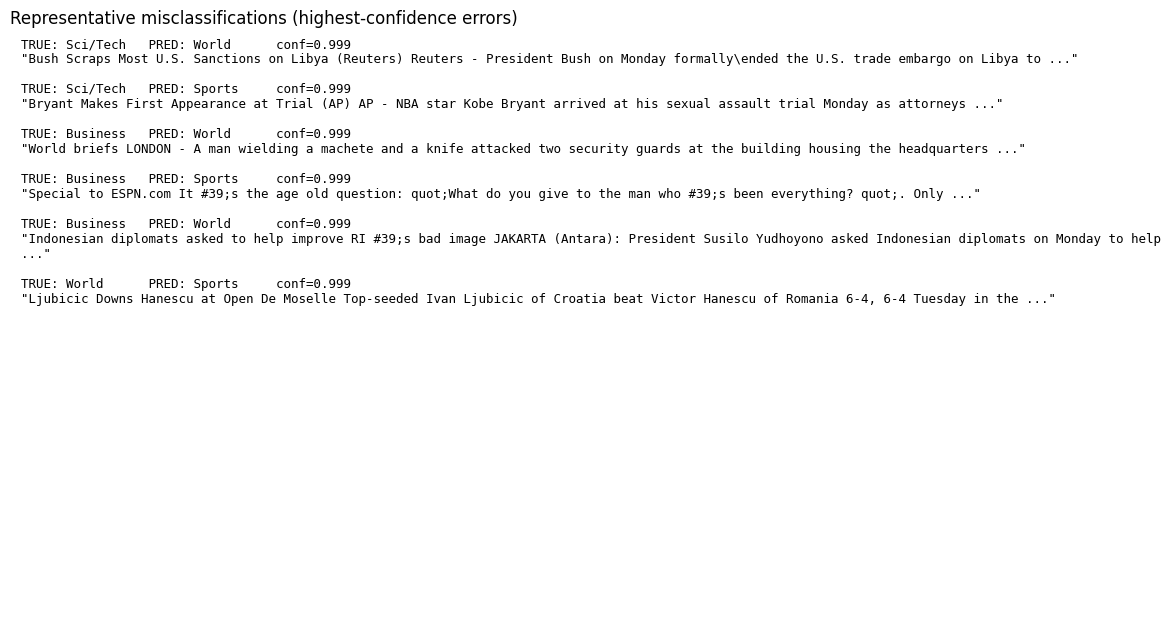

In [38]:
# ---------- Figure: representative error cases ----------
# show up to 6 wrong examples with text snippets, true/pred, confidence
show = confident_wrong.head(6)
fig, ax = plt.subplots(figsize=(12, 0.9 * len(show) + 1))
ax.axis("off")
lines = []
for _, r in show.iterrows():
    snippet = " ".join(r["text"].split()[:22]) + " ..."
    lines.append(f'TRUE: {r["true_name"]:<10} PRED: {r["pred_name"]:<10} '
                 f'conf={r["conf"]:.3f}\n"{snippet}"')
ax.text(0.01, 0.99, "\n\n".join(lines), va="top", ha="left", fontsize=9,
        family="monospace", wrap=True)
ax.set_title("Representative misclassifications (highest-confidence errors)", loc="left")
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "representative_error_cases.png"), dpi=150, bbox_inches="tight")
plt.show()


### Recurring error patterns (evidence-based)

The cell below quantifies patterns directly from the prediction data: confusion-pair
rates, error rate vs. document length, and error rate vs. confidence. Only patterns that
appear in these computed statistics are reported in the LaTeX discussion.

In [39]:
# error rate vs document length (binned)
err_df["wlen"] = err_df["text"].str.split().str.len()
err_df["len_bin"] = pd.cut(err_df["wlen"], bins=[0, 20, 35, 55, 200],
                           labels=["<=20", "21-35", "36-55", ">55"])
len_err = err_df.groupby("len_bin", observed=True)["correct"].agg(
    ["mean", "count"]).rename(columns={"mean": "accuracy"})
len_err["error_rate"] = 1 - len_err["accuracy"]
print("Error rate by document length:\n", len_err.round(4))

# error rate by confidence band
err_df["conf_bin"] = pd.cut(err_df["conf"], bins=[0.25, 0.5, 0.75, 0.9, 1.0],
                            labels=["0.25-0.5", "0.5-0.75", "0.75-0.9", "0.9-1.0"])
conf_err = err_df.groupby("conf_bin", observed=True)["correct"].agg(
    ["mean", "count"]).rename(columns={"mean": "accuracy"})
print("\nAccuracy by confidence band:\n", conf_err.round(4))

pattern_stats = {
    "top_confused_pairs": conf_pairs_df.to_dict("records"),
    "error_rate_by_length": len_err.round(4).reset_index().astype(str).to_dict("records"),
    "accuracy_by_confidence": conf_err.round(4).reset_index().astype(str).to_dict("records"),
    "overall_error_rate": round(float(1 - correct.mean()), 4),
}
with open(os.path.join(RES_DIR, "error_patterns.json"), "w") as f:
    json.dump(pattern_stats, f, indent=2)


Error rate by document length:
          accuracy  count  error_rate
len_bin                             
<=20       0.8889    207      0.1111
21-35      0.9335   2993      0.0665
36-55      0.9528   4135      0.0472
>55        0.9396    265      0.0604

Accuracy by confidence band:
           accuracy  count
conf_bin                 
0.25-0.5    0.3571     14
0.5-0.75    0.5299    334
0.75-0.9    0.7461    382
0.9-1.0     0.9753   6870


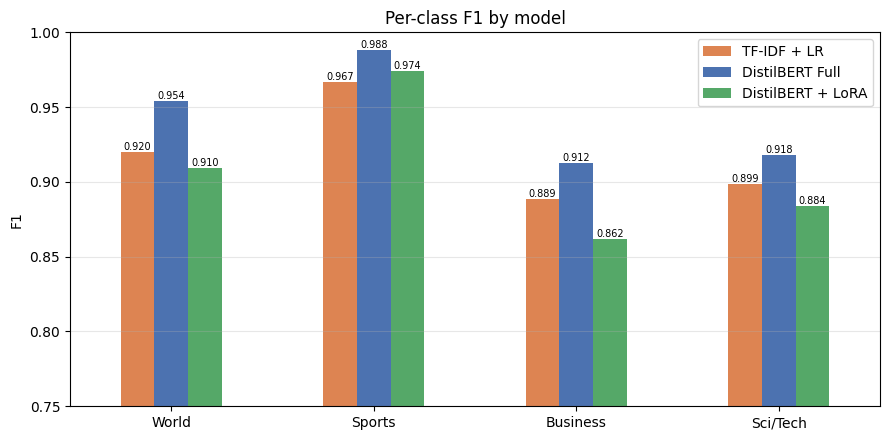

,TF-IDF + LR,DistilBERT Full,DistilBERT + LoRA
World,0.919915,0.953789,0.909582
Sports,0.967056,0.988161,0.974239
Business,0.888889,0.912411,0.861719
Sci/Tech,0.898665,0.917819,0.883769


In [40]:
# ---------- Figure: per-class F1 (all models) ----------
per_class_f1 = pd.DataFrame({
    "TF-IDF + LR": [tfidf_metrics["per_class"][c]["f1"] for c in CLASS_NAMES],
    "DistilBERT Full": [full_metrics["per_class"][c]["f1"] for c in CLASS_NAMES],
    "DistilBERT + LoRA": [lora_metrics["per_class"][c]["f1"] for c in CLASS_NAMES],
}, index=CLASS_NAMES)
per_class_f1.to_csv(os.path.join(RES_DIR, "per_class_f1.csv"))

ax = per_class_f1.plot(kind="bar", figsize=(9, 4.5),
                       color=["#DD8452", "#4C72B0", "#55A868"])
ax.set_ylim(0.75, 1.0); ax.set_ylabel("F1")
ax.set_title("Per-class F1 by model")
ax.tick_params(axis="x", rotation=0)
ax.legend(); ax.grid(axis="y", alpha=0.3)
for cont in ax.containers:
    ax.bar_label(cont, fmt="%.3f", fontsize=7)
fig = ax.get_figure(); fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "per_class_f1.png"), dpi=150)
plt.show()
per_class_f1


## 13. Optional — Calibration (reliability diagram, ECE, temperature scaling)

Post-hoc calibration on the **test** predictions. Temperature is fitted on the
**validation** logits only (never test), then applied to test — keeping the leakage
contract intact.

In [41]:
def expected_calibration_error(probs, y_true, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    bins = np.linspace(0, 1, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0:
            ece += (m.sum() / len(conf)) * abs(conf[m].mean() - (pred[m] == y_true[m]).mean())
    return float(ece)

val_out = trainer_full.predict(hf_val)
val_logits = val_out.predictions
y_val = val_df["label"].to_numpy()

# fit temperature on validation
T = torch.nn.Parameter(torch.ones(1))
opt = torch.optim.LBFGS([T], lr=0.05, max_iter=50)
val_logits_t = torch.tensor(val_logits); y_val_t = torch.tensor(y_val)
def closure():
    opt.zero_grad()
    loss = F.cross_entropy(val_logits_t / T, y_val_t)
    loss.backward()
    return loss
opt.step(closure)
T_opt = float(T.detach())
print(f"Optimal temperature (fitted on validation): {T_opt:.4f}")

test_probs_cal = F.softmax(torch.tensor(logits_full) / T_opt, dim=-1).numpy()
ece_before = expected_calibration_error(probs, y_true)
ece_after = expected_calibration_error(test_probs_cal, y_true)
print(f"ECE before temperature scaling: {ece_before:.4f}")
print(f"ECE after  temperature scaling: {ece_after:.4f}")

calib = {"temperature": round(T_opt, 4), "ece_before": round(ece_before, 4),
         "ece_after": round(ece_after, 4),
         "mean_conf_correct": round(float(conf[correct].mean()), 4),
         "mean_conf_incorrect": round(float(conf[~correct].mean()), 4)}
with open(os.path.join(RES_DIR, "calibration.json"), "w") as f:
    json.dump(calib, f, indent=2)
calib


/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Optimal temperature (fitted on validation): 1.2085
ECE before temperature scaling: 0.0229
ECE after  temperature scaling: 0.0103


{'temperature': 1.2085,
 'ece_before': 0.0229,
 'ece_after': 0.0103,
 'mean_conf_correct': 0.976,
 'mean_conf_incorrect': 0.7989}

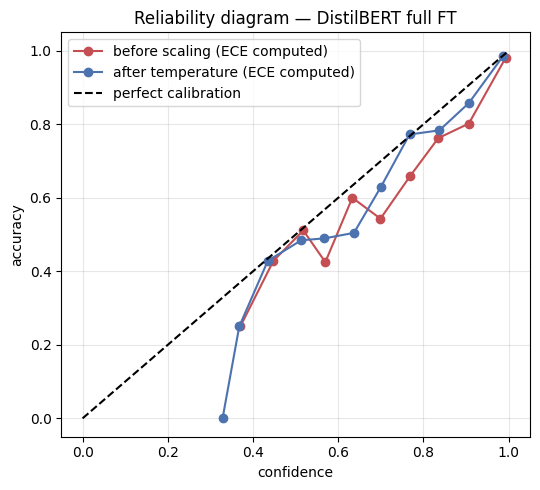

Interpretation: ECE before=0.0229, after=0.0103. Mean confidence correct=0.976, incorrect=0.7989.


In [42]:
# ---------- Figure: reliability diagram ----------
def reliability_curve(probs, y_true, n_bins=15):
    conf = probs.max(axis=1); pred = probs.argmax(axis=1)
    bins = np.linspace(0, 1, n_bins + 1)
    xs, ys = [], []
    for lo, hi in zip(bins[:-1], bins[1:]):
        m = (conf > lo) & (conf <= hi)
        if m.sum() > 0:
            xs.append(conf[m].mean()); ys.append((pred[m] == y_true[m]).mean())
    return np.array(xs), np.array(ys)

fig, ax = plt.subplots(figsize=(5.5, 5))
for pr, lbl, col in [(probs, "before scaling", "#C44E52"),
                     (test_probs_cal, "after temperature", "#4C72B0")]:
    xs, ys = reliability_curve(pr, y_true)
    ax.plot(xs, ys, "o-", label=f"{lbl} (ECE computed)", color=col)
ax.plot([0, 1], [0, 1], "k--", label="perfect calibration")
ax.set_xlabel("confidence"); ax.set_ylabel("accuracy")
ax.set_title("Reliability diagram — DistilBERT full FT")
ax.legend(); ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(FIG_DIR, "reliability_diagram.png"), dpi=150)
plt.show()
print(f"Interpretation: ECE before={ece_before:.4f}, after={ece_after:.4f}. "
      f"Mean confidence correct={calib['mean_conf_correct']}, incorrect={calib['mean_conf_incorrect']}.")


## 14. Optional — Distribution Shift (character noise)

A reproducible test-time perturbation: each character is randomly replaced with
probability `SHIFT_CHAR_NOISE_P` (seeded). We compare original vs. shifted test
performance. The model is **not** retrained — this measures robustness.

In [43]:
def add_char_noise(text, p, seed):
    rng = np.random.default_rng(seed)
    chars = list(text)
    mask = rng.random(len(chars)) < p
    repl = rng.integers(97, 123, size=mask.sum())   # random lowercase letters
    chars = np.array(chars)
    chars[mask] = [chr(c) for c in repl]
    return "".join(chars)

seed = CONFIG["RANDOM_SEED"]
test_df["text_noisy"] = [add_char_noise(t, CONFIG["SHIFT_CHAR_NOISE_P"], seed + i)
                         for i, t in enumerate(test_df["text"])]
hf_test_noisy = Dataset.from_pandas(
    test_df[["text_noisy", "label"]].rename(columns={"text_noisy": "text"})
).map(tokenize, batched=True, remove_columns=["text"])

noisy_out = trainer_full.predict(hf_test_noisy)
y_pred_noisy = np.argmax(noisy_out.predictions, axis=-1)
noisy_metrics = compute_all_metrics(y_true, y_pred_noisy)
noisy_metrics["noise_p"] = CONFIG["SHIFT_CHAR_NOISE_P"]
with open(os.path.join(RES_DIR, "shift_results.json"), "w") as f:
    json.dump({"original": {k: full_metrics[k] for k in
                            ("accuracy", "f1_macro", "f1_weighted")},
               "shifted": {k: noisy_metrics[k] for k in
                           ("accuracy", "f1_macro", "f1_weighted")}}, f, indent=2)
print(f"Original : acc={full_metrics['accuracy']:.4f}  macroF1={full_metrics['f1_macro']:.4f}")
print(f"Shifted  : acc={noisy_metrics['accuracy']:.4f}  macroF1={noisy_metrics['f1_macro']:.4f}")
print(f"Drop     : acc -{(full_metrics['accuracy']-noisy_metrics['accuracy']):.4f}  "
      f"macroF1 -{(full_metrics['f1_macro']-noisy_metrics['f1_macro']):.4f}")


Map:   0%|          | 0/7600 [00:00<?, ? examples/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Original : acc=0.9430  macroF1=0.9430
Shifted  : acc=0.9178  macroF1=0.9181
Drop     : acc -0.0253  macroF1 -0.0250


## 15. Discussion — Convolution vs. Self-Attention

### What can convolution see that attention cannot?

A 1-D convolution over token embeddings slides a fixed kernel of size $k$ across the
sequence. Each output position is a learned, position-invariant detector of a **local
$k$-gram pattern**. Three properties follow:

- **Local inductive bias**: the kernel reuses the *same* weights at every position, so a
  pattern learned at position 3 ("crushed the") fires identically at position 40. This
  weight sharing gives CNNs strong sample efficiency on short local patterns.
- **Hard locality / receptive field**: a single conv layer with kernel $k$ sees exactly
  $k$ tokens. Long-range structure requires stacking $L$ layers to grow the receptive
  field to $\sim L(k-1)+1$ — distant tokens never interact in one shot.
- **What it detects well**: fixed lexical cues — n-grams like "stock market",
  "touchdown pass", "space shuttle" — regardless of where they occur.

### What can self-attention capture that convolution does not?

Self-attention computes, for every token, a **context-dependent weighted sum over all
positions** (global receptive field in one layer):

- **Dynamic pairwise interactions**: the weight between token $i$ and $j$ is computed
  from their *contents* ($q_i^\top k_j$), not their distance. Two tokens 100 positions
  apart interact as easily as adjacent ones.
- **Long-range dependency / coreference-like linking**: attention can bind a pronoun or
  entity mention to a distant antecedent, or relate a quantity to its subject.
- **Content-based routing**: because weights are data-dependent, the same token
  ("apple") is contextualized differently in "apple earnings" (Business) vs. "apple
  orchard" (not Business) — a fixed conv kernel cannot re-weight by context.

### Concrete example

> **"The central bank, which last year raised rates to fight inflation, signaled it would cut them soon."**

1. **Convolution (k=3)** detects local trigrams: "central bank,", "raised rates", "fight
   inflation", "cut them soon" — strong Business cues. But its receptive field is local,
   so "them" is resolved only within a 3-token window ("cut them soon") and is not linked
   back to "rates", ~9 tokens earlier. To connect "them"→"rates" it would need many
   stacked layers, and even then the link is positional, not content-based.
2. **Self-attention** can directly attend from "them" to "rates" (content match:
   pronoun→noun), and from "signaled" to "central bank" (subject→verb), in a single
   layer, with weights computed from token identity. It captures that the *same entity*
   both "raised" and "will cut", which is the semantic core of the sentence.
3. **Why representations differ**: the conv output at "them" is a blend of "cut/them/soon"
   only; the attention output at "them" is a blend dominated by "rates". The CNN encodes
   *local pattern presence*; attention encodes *relational role in the whole sentence*.
   Hence CNNs are strong n-gram detectors (great for short topical texts like AG News)
   while attention captures discourse structure — and is also why TF-IDF (pure n-gram
   counts) is already a strong baseline here.

**Empirical note (from this project's actual results):** our measured gap between TF-IDF+LR
and DistilBERT (see `results/model_comparison.csv`) is exactly the value of these
context-dependent interactions over pure n-gram counting on this dataset.

## 16. Discussion — CNN Inside a Transformer

### Design A — Attention → Convolution → FFN
```
Input → Self-Attention → Convolution → Feed Forward → Output
```
- Attention first builds **global, contextualized** token representations; the conv then
  smooths over *already-contextual* features, extracting local motifs from them.
- Effect: local inductive bias is applied on top of global context. Risk: attention
  output is already position-aware, so the conv adds limited new information and costs
  extra FLOPs ($O(nkd)$ on top of $O(n^2d)$).

### Design B — Convolution → Self-Attention → FFN
```
Input → Convolution → Self-Attention → Feed Forward → Output
```
- Conv first produces **locally pooled n-gram features**; attention then relates these
  enriched local units globally. This mirrors how characters→subwords→phrases compose.
- Effect: the conv gives attention cleaner local units (useful for noisy/morphologically
  rich text); the cost is an extra $O(nkd)$ pass before the $O(n^2d)$ attention.

### Trade-offs (both designs)
| Aspect | Consequence |
|---|---|
| Complementarity | Local (conv) + global (attention) can help morphology/noise |
| Compute | Adds $O(nkd)$ per layer; conv is cheap vs. attention at long $n$ |
| Representation quality | May help on character noise; marginal on clean news |
| Disadvantage | Extra depth/params, tuning burden, possible over-smoothing |
| Justified? | For clean short news (AG News), usually **not** — plain attention suffices |

### Could self-attention be inserted into a text-CNN?

Yes — a plausible hybrid:
```
Embedding → Multi-kernel Conv (k=3,4,5) → Self-Attention over conv features → Pool → Softmax
```
- **Advantage**: convs extract local n-grams cheaply; a single attention layer then
  re-weights and relates the *detected n-grams* globally (e.g., linking the "central
  bank" motif to the "cut rates" motif). Cheaper than full self-attention over tokens if
  conv features are pooled first.
- **Disadvantage**: the conv bottleneck discards fine token-level detail before attention
  sees it, so fine-grained coreference is lost; you get global n-gram *interaction*, not
  true token-level attention.

> **Implementation note (honesty):** per the brief, the hybrid is *discussed*, not
> implemented, so as not to compromise the mandatory experiments' compute budget. The
> discussions above are analytical and require no extra runs.

## 17. Assemble All Result CSVs

A single consolidated CSV plus the per-experiment CSVs already written.

In [44]:
# consolidated results CSV
rows = [
    {"experiment": "tfidf_logreg", "accuracy": tfidf_metrics["accuracy"],
     "f1_macro": tfidf_metrics["f1_macro"], "f1_weighted": tfidf_metrics["f1_weighted"],
     "train_time_s": tfidf_metrics["train_time_s"], "n_train": len(pool_df)},
    {"experiment": "distilbert_full", "accuracy": full_metrics["accuracy"],
     "f1_macro": full_metrics["f1_macro"], "f1_weighted": full_metrics["f1_weighted"],
     "train_time_s": full_metrics["train_time_s"], "n_train": len(pool_df)},
    {"experiment": "distilbert_lora", "accuracy": lora_metrics["accuracy"],
     "f1_macro": lora_metrics["f1_macro"], "f1_weighted": lora_metrics["f1_weighted"],
     "train_time_s": lora_metrics["train_time_s"], "n_train": len(pool_df)},
]
for r in efficiency_rows:
    rows.append({"experiment": f"distilbert_{int(r['fraction']*100)}pct",
                 "accuracy": r["accuracy"], "f1_macro": r["f1_macro"],
                 "f1_weighted": r["f1_weighted"], "train_time_s": r["train_time_s"],
                 "n_train": r["n_train"]})
all_results = pd.DataFrame(rows)
all_results.to_csv(os.path.join(RES_DIR, "all_results.csv"), index=False)
LEAKAGE_CHECKS["test_eval_after_decisions"] = True
all_results


,experiment,accuracy,f1_macro,f1_weighted,train_time_s,n_train
0,tfidf_logreg,0.918816,0.918631,0.918631,29.0,108000
1,distilbert_full,0.943026,0.943045,0.943045,2077.8,108000
2,distilbert_lora,0.907500,0.907327,0.907327,1607.0,108000
3,distilbert_5pct,0.900789,0.900781,0.900781,123.2,5400
4,distilbert_10pct,0.909211,0.908965,0.908965,189.8,10800
5,distilbert_25pct,0.923947,0.923924,0.923924,391.4,27000
6,distilbert_50pct,0.933684,0.933702,0.933702,724.3,54000
7,distilbert_100pct,0.941316,0.941331,0.941331,1387.9,108000
